# Feature–feature attention: with logic vs. without

Reloads the two single-run checkpoints saved by `AttentionEncoder.ipynb` and
`AttentionEncoder_noLTN.ipynb`, replays the test set through each, and renders
the pair of mean attention maps side by side as a **vector PDF** for the
response letter.

| | checkpoint | notebook |
|---|---|---|
| with logic | `./saved/attn_kan_2_6.pt` | `AttentionEncoder.ipynb` |
| without logic | `./saved/attn_kan_noLTN_2_6.pt` | `AttentionEncoder_noLTN.ipynb` |

Inference only — nothing is trained. Single seed (42), matching the two
notebooks; this is an illustrative figure, not a statistical claim.

Output → `./figures/attention_pair.pdf` (+ `.png`), and optionally
`attention_diff.pdf`.

All styling is in the **Figure config** cell. Retune there and re-run the
figure cells; the cells above it don't need re-running.

In [1]:
# --- Setup ---
import os, sys, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('.'))
sys.path.append(os.path.abspath('../P1_structurelevel'))

from utils import MultiKANModel
from attention_modules import AttentionKANModel
from kan import KAN

warnings.filterwarnings('ignore', category=UserWarning)

# Same device policy as the two source notebooks: CUDA or CPU, never MPS.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


In [2]:
# --- Config ---
CKPTS = {
    'with logic':    './saved/attn_kan_2_6.pt',
    'without logic': './saved/attn_kan_noLTN_2_6.pt',
}
TEST_PATH = '../P1_structurelevel/efficiency/input_files/logiKNet_test_3994.csv'
OUT_DIR   = './figures'
os.makedirs(OUT_DIR, exist_ok=True)

# Panel titles as they should read in the paper.
# Macro is \attnlogiknet{} = "Attn-LogiK-Net" (Major-Revision-Response.tex).
PANEL_TITLES = {
    'with logic':    'Attn-LogiK-Net (full)',
    'without logic': 'Attn-LogiK-Net (no logic)',
}

# Shorter axis labels; keys must match X_columns stored in the checkpoint.
LABEL_OVERRIDE = {
    'Header_Length': 'Header Len',
    'Protocol Type': 'Protocol',
    'Tot sum': 'Tot Sum',
    'Tot size': 'Tot Size',
    'Magnitue': 'Magnitude',   # source column is misspelled; fix on the axis only
}

In [3]:
# --- Load test data (scaler comes from the checkpoint) ---
_probe = torch.load(CKPTS['with logic'], map_location='cpu', weights_only=False)
CFG = _probe['config']
X_columns   = CFG['X_columns']
IN_FEATURES = CFG['IN_FEATURES']
FEAT_LABELS = [LABEL_OVERRIDE.get(c, c) for c in X_columns]

# Preflight: the CSVs are tracked by Git LFS (.gitattributes: *.csv filter=lfs).
# In a clone without the LFS objects fetched they are ~130-byte pointer stubs,
# and pandas parses them into a 1-column frame -> a confusing KeyError below.
with open(TEST_PATH, 'rb') as _f:
    if _f.read(40).startswith(b'version https://git-lfs'):
        raise RuntimeError(
            f"{TEST_PATH} is a Git LFS pointer, not the actual CSV.\n"
            "Fetch the data first, from the repo root:\n"
            "    git lfs install\n"
            "    git lfs pull\n"
            "Then re-run this cell.")

test_df = pd.read_csv(TEST_PATH)
missing = [c for c in X_columns if c not in test_df.columns]
if missing:
    raise KeyError(
        f"{len(missing)} feature column(s) from the checkpoint are absent from "
        f"{TEST_PATH}: {missing}\nCSV has: {list(test_df.columns)}")

X = test_df[X_columns].values.astype(np.float32)
X = (X - np.asarray(_probe['scaler_mean'])) / np.asarray(_probe['scaler_scale'])
X_t = torch.tensor(X, dtype=torch.float32, device=device)

print(f'test set: {X.shape[0]} flows x {IN_FEATURES} features')

test set: 3994 flows x 18 features


In [4]:
# --- Reload each checkpoint and average its attention over the test set ---
def load_model(path):
    """Rebuild AttentionKANModel from a state_dict checkpoint.

    pykan's symbolic lambdas aren't in the state_dict -- fine, we only need
    numeric-mode inference. The seed passed to KAN() only affects the random
    init that load_state_dict immediately overwrites.
    """
    ck = torch.load(path, map_location=device, weights_only=False)
    cfg = ck['config']
    kan = KAN(width=cfg['KAN_WIDTH'], grid=5, k=3, seed=cfg['SEED'],
              device=device, auto_save=False, save_act=False)
    model = AttentionKANModel(cfg['IN_FEATURES'], MultiKANModel(kan),
                              **cfg['ATTN']).to(device)
    model.load_state_dict(ck['model_state'])
    model.eval()
    return model, ck


CHUNK = 512   # chunked so the [B, F, F] attention stack stays small

def mean_attention(model, X_t):
    """Mean last-layer attention map [F, F] over the whole test set."""
    tot = np.zeros((X_t.shape[1], X_t.shape[1]), dtype=np.float64)
    with torch.no_grad():
        for s in range(0, X_t.shape[0], CHUNK):
            _ = model(X_t[s:s+CHUNK], training=False)
            tot += model.last_attention().cpu().numpy().astype(np.float64).sum(0)
    return tot / X_t.shape[0]


A = {}
for tag, path in CKPTS.items():
    model, ck = load_model(path)
    A[tag] = mean_attention(model, X_t)
    fin = ck.get('final', {})
    print(f"{tag:15s} | rows sum to {A[tag].sum(1).mean():.4f} (expect 1.0) | "
          + " ".join(f"{k} {v:.4f}" for k, v in fin.items()))
    del model

with logic      | rows sum to 1.0000 (expect 1.0) | acc 0.7969 sat 0.6443 reliable 0.8758
without logic   | rows sum to 1.0000 (expect 1.0) | acc 0.8085 reliable 0.8861


---
## Figure config

Tune here, then re-run the figure cells below.

In [11]:
# --- Figure config ---
from matplotlib import font_manager

# Font stack, first available wins. Matplotlib falls back SILENTLY, which is why
# a figure can look wrong with no warning -- resolve_font() makes it explicit.
FONT_STACK = ['Times New Roman', 'Nimbus Roman', 'Liberation Serif',
              'STIX Two Text', 'DejaVu Serif']

def resolve_font(stack):
    avail = {f.name for f in font_manager.fontManager.ttflist}
    for name in stack:
        if name in avail:
            return name, avail
    return None, avail

FONT, _avail = resolve_font(FONT_STACK)
if FONT is None:
    print('WARNING: none of', FONT_STACK, 'found; using matplotlib default.')
    FONT = 'DejaVu Serif'
elif FONT != FONT_STACK[0]:
    print(f'NOTE: "{FONT_STACK[0]}" not installed -> falling back to "{FONT}".')
    print('      Serif fonts available here:',
          sorted(n for n in _avail if any(k in n for k in
                 ('Times', 'Roman', 'Serif', 'STIX', 'Georgia', 'Palatino'))))
else:
    print(f'font: {FONT}')

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': [FONT],
    'mathtext.fontset': 'stix',      # Times-compatible math; embeds as TrueType
    'font.size': 8,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size': 2.5,
    'ytick.major.size': 2.5,
    'figure.dpi': 130,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,

    # --- Font embedding: the setting IEEE PDF eXpress cares about -----------
    # 3  = Type 3 (matplotlib's DEFAULT) -- glyphs as raw PostScript drawing
    #      ops, text not selectable/searchable. This is what gets REJECTED.
    # 42 = TrueType. Text stays real text. Use this.
    # (Both are also accepted by Overleaf/pdflatex without complaint, so a
    #  Type 3 figure fails only at submission -- hence the late surprise.)
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    # -----------------------------------------------------------------------
})

PAGE_W = 7.16      # IEEE double-column width, inches
COL_W  = 3.5       # IEEE single-column width, inches

CMAP     = 'viridis'    # 'viridis' | 'magma' | 'cividis' | 'YlGnBu'
CMAP_DIV = 'RdBu_r'     # signed difference map
SHARED_SCALE = True     # True -> both panels share one colour scale (comparable)
GRIDLINES    = True
SAVE_FORMATS = ['pdf', 'png']

# X tick label rotation. 45 is the readable/compact compromise: at 90 the labels
# are a tall vertical block (here ~0.9 in of pure text under each panel), at 45
# they occupy ~0.7x that height and read on a natural diagonal. Below ~30 the
# 18 labels start colliding horizontally.
XTICK_ROT = 40          # try 45 | 30 | 60 | 90 | 0


def set_xticklabels_rot(ax, labels, rot=None):
    """Set rotated x tick labels with correct anchoring.

    A plain rotation=45 pivots about the label CENTRE, so the text drifts right
    of its tick and the last label overhangs the axes. Anchoring at the right
    end (ha='right', rotation_mode='anchor') pins each label's top-right corner
    to its tick, which is what makes angled labels line up.
    """
    rot = XTICK_ROT if rot is None else rot
    if 0 < rot < 90:
        ax.set_xticklabels(labels, rotation=rot, ha='right', va='top',
                           rotation_mode='anchor')
    else:
        ax.set_xticklabels(labels, rotation=rot,
                           ha='center' if rot in (0, 90) else 'right')


def check_no_type3(pdf_path):
    """Fail loudly if the emitted PDF contains a Type 3 font.

    Prefers `pdffonts` (poppler) when present -- that is the same information
    PDF eXpress reports. Falls back to scanning the raw bytes for /Type3, which
    is a reliable enough signal for matplotlib output.
    """
    import shutil, subprocess
    if shutil.which('pdffonts'):
        out = subprocess.run(['pdffonts', pdf_path], capture_output=True,
                             text=True).stdout
        bad = [ln for ln in out.splitlines() if 'Type 3' in ln]
        if bad:
            raise RuntimeError(f'Type 3 font in {pdf_path}:\n' + '\n'.join(bad))
        return out
    with open(pdf_path, 'rb') as f:
        if b'/Type3' in f.read():
            raise RuntimeError(
                f'Type 3 font detected in {pdf_path} -- check pdf.fonttype.')
    return None


def save_fig(fig, name, verify=True):
    for ext in SAVE_FORMATS:
        path = os.path.join(OUT_DIR, f'{name}.{ext}')
        fig.savefig(path, format=ext)
        if verify and ext == 'pdf':
            rep = check_no_type3(path)
            if rep:
                print(rep.strip())
    print('saved:', ', '.join(os.path.join(OUT_DIR, f'{name}.{e}')
                              for e in SAVE_FORMATS), '| no Type 3 fonts')


def heatmap(ax, M, cmap=CMAP, vmin=None, vmax=None, xlabel='', ylabel=''):
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest', aspect='equal')
    ax.set_xticks(range(IN_FEATURES)); ax.set_yticks(range(IN_FEATURES))
    set_xticklabels_rot(ax, FEAT_LABELS)
    ax.set_yticklabels(FEAT_LABELS)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if GRIDLINES:
        ax.set_xticks(np.arange(-.5, IN_FEATURES, 1), minor=True)
        ax.set_yticks(np.arange(-.5, IN_FEATURES, 1), minor=True)
        ax.grid(which='minor', color='w', linewidth=0.3)
        ax.tick_params(which='minor', length=0)
    for s in ax.spines.values():
        s.set_linewidth(0.6)
    return im

font: Times New Roman


### The figure

Row *i* is the attention distribution of query feature *i* over all key
features, so rows sum to 1. Averaged over the 3,994 test flows.

saved: ./figures/attention_pair.pdf, ./figures/attention_pair.png | no Type 3 fonts


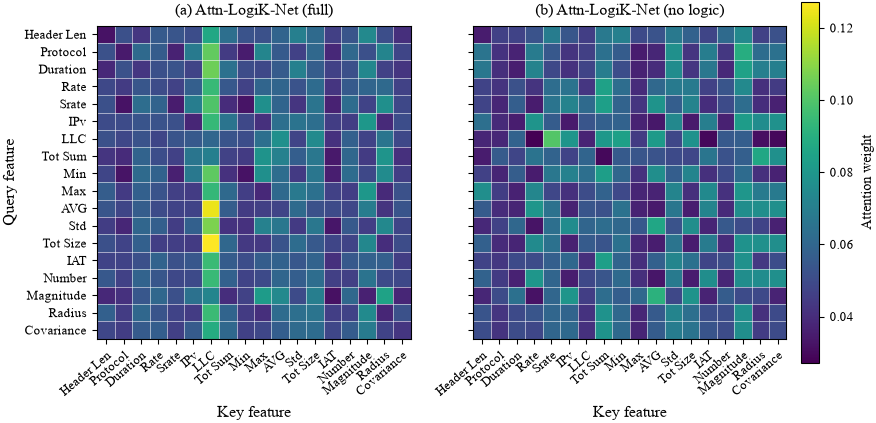

In [12]:
tags = list(CKPTS)
if SHARED_SCALE:
    vmin = min(A[t].min() for t in tags)
    vmax = max(A[t].max() for t in tags)
else:
    vmin = vmax = None

fig, axes = plt.subplots(1, 2, figsize=(PAGE_W, PAGE_W * 0.52))

for k, (ax, tag) in enumerate(zip(axes, tags)):
    im = heatmap(ax, A[tag], vmin=vmin, vmax=vmax,
                 xlabel='Key feature',
                 ylabel='Query feature' if k == 0 else '')
    if k:
        ax.set_yticklabels([])
    ax.set_title(f'({chr(97+k)}) {PANEL_TITLES[tag]}', loc='center', pad=6)

if SHARED_SCALE:
    cb = fig.colorbar(im, ax=axes.tolist(), fraction=0.025, pad=0.02)
    cb.set_label('Attention weight', fontsize=8)
    cb.ax.tick_params(labelsize=7); cb.outline.set_linewidth(0.6)
else:
    for ax in axes:
        cb = fig.colorbar(ax.images[0], ax=ax, fraction=0.046, pad=0.03)
        cb.ax.tick_params(labelsize=7); cb.outline.set_linewidth(0.6)
    fig.tight_layout()

save_fig(fig, 'attention_pair')
plt.show()

### Optional: difference map

`with logic − without logic`. Red = the LTN objective pushes attention up on
that (query, key) pair, blue = down. Useful if you want to argue the logic layer
changes *how* the model routes information rather than how accurately it scores.
Skip this cell if you only need the pair above.

saved: ./figures/attention_diff.pdf, ./figures/attention_diff.png | no Type 3 fonts


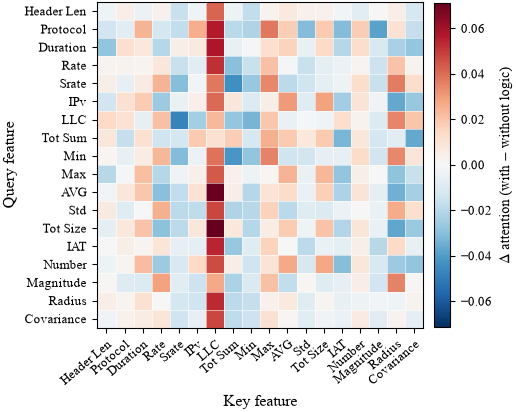

max |shift|  : 0.0713
mean |shift| : 0.0152

largest shifts (query -> key):
      Tot Size -> LLC          +0.0713
           AVG -> LLC          +0.0705
      Duration -> LLC          +0.0577
      Protocol -> LLC          +0.0568
           IAT -> LLC          +0.0546
        Radius -> LLC          +0.0533
          Rate -> LLC          +0.0519
           Std -> LLC          +0.0477


In [13]:
D = A['with logic'] - A['without logic']
lim = np.abs(D).max()

fig, ax = plt.subplots(figsize=(COL_W, COL_W * 0.95))
im = heatmap(ax, D, cmap=CMAP_DIV, vmin=-lim, vmax=lim,
             xlabel='Key feature', ylabel='Query feature')
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
cb.set_label(r'$\Delta$ attention (with $-$ without logic)', fontsize=8)
cb.ax.tick_params(labelsize=7); cb.outline.set_linewidth(0.6)
save_fig(fig, 'attention_diff')
plt.show()

print(f'max |shift|  : {lim:.4f}')
print(f'mean |shift| : {np.abs(D).mean():.4f}\n')
iy, ix = np.unravel_index(np.argsort(np.abs(D).ravel())[::-1][:8], D.shape)
print('largest shifts (query -> key):')
for a_, b_ in zip(iy, ix):
    print(f'  {FEAT_LABELS[a_]:>12s} -> {FEAT_LABELS[b_]:<12s} {D[a_, b_]:+.4f}')

### Optional: which features receive the most attention

Column means of each map — how much every other feature attends *to* this one.
Worth a glance to see whether the ranking lines up with the features your LTN
rules and the KAN attribution scores
(`P1_structurelevel/output/*_attribution_scores.pdf`) rely on.

saved: ./figures/attention_importance.pdf, ./figures/attention_importance.png | no Type 3 fonts


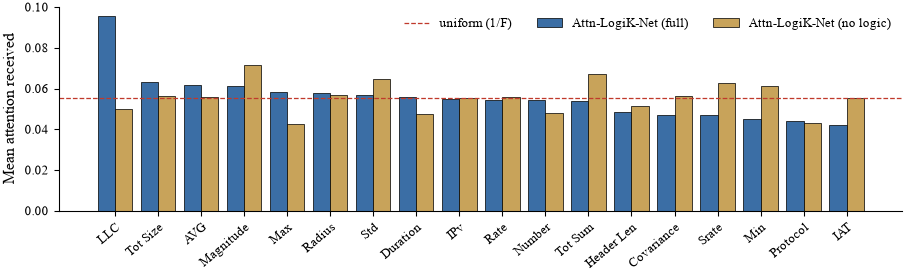

rank  feature              with   without
   1  LLC                0.0954    0.0498
   2  Tot Size           0.0632    0.0562
   3  AVG                0.0615    0.0557
   4  Magnitude          0.0611    0.0715
   5  Max                0.0583    0.0425
   6  Radius             0.0579    0.0567
   7  Std                0.0567    0.0647
   8  Duration           0.0559    0.0473
   9  IPv                0.0547    0.0552
  10  Rate               0.0541    0.0557
  11  Number             0.0541    0.0479
  12  Tot Sum            0.0540    0.0669
  13  Header Len         0.0484    0.0512
  14  Covariance         0.0470    0.0563
  15  Srate              0.0469    0.0625
  16  Min                0.0448    0.0611
  17  Protocol           0.0438    0.0431
  18  IAT                0.0421    0.0554


In [14]:
recv = {t: A[t].mean(axis=0) for t in tags}
order = np.argsort(recv['with logic'])[::-1]
w = 0.4
x = np.arange(IN_FEATURES)

fig, ax = plt.subplots(figsize=(PAGE_W, 2.3))
ax.bar(x - w/2, recv['with logic'][order], w, label=PANEL_TITLES['with logic'],
       color='#3b6ea5', edgecolor='black', linewidth=0.4)
ax.bar(x + w/2, recv['without logic'][order], w, label=PANEL_TITLES['without logic'],
       color='#c8a35a', edgecolor='black', linewidth=0.4)
ax.axhline(1/IN_FEATURES, ls='--', lw=0.7, color='#c0392b', label='uniform (1/F)')
ax.set_xticks(x)
set_xticklabels_rot(ax, [FEAT_LABELS[i] for i in order])
ax.set_ylabel('Mean attention received')
ax.legend(frameon=False, ncol=3, fontsize=7)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.tight_layout()
save_fig(fig, 'attention_importance')
plt.show()

print(f'{"rank":>4}  {"feature":<16}{"with":>9}{"without":>10}')
for r, i in enumerate(order, 1):
    print(f'{r:>4}  {FEAT_LABELS[i]:<16}'
          f'{recv["with logic"][i]:>9.4f}{recv["without logic"][i]:>10.4f}')